# Customer360 — Customer Behavior & Churn Analytics
## 01 | Data Cleaning and Exploratory Data Analysis

This notebook inspects the supplied IBM Telco customer churn data, documents a minimal numeric conversion for `TotalCharges`, explores customer and churn patterns, calculates requested KPIs, and saves a cleaned copy. It does **not** train machine learning models. The raw CSV is read only and remains unchanged.

## 1. Setup and load the raw dataset

The notebook checks the project root from the current working directory so it can run from either the project root or `notebooks/`.

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)
sns.set_theme(style="whitegrid", palette="deep")

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data" / "raw" / "dataset.csv").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
RAW_PATH = PROJECT_ROOT / "data" / "raw" / "dataset.csv"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
CLEANED_PATH = PROCESSED_DIR / "customer_churn_cleaned.csv"

if not RAW_PATH.exists():
    raise FileNotFoundError(f"Raw dataset not found: {RAW_PATH}")

raw_df = pd.read_csv(RAW_PATH)
df = raw_df.copy(deep=True)
print(f"Loaded raw data from: {RAW_PATH}")
print(f"Raw DataFrame shape: {raw_df.shape[0]:,} rows × {raw_df.shape[1]} columns")
display(raw_df.head())

Loaded raw data from: C:\Users\Lenovo\OneDrive\Desktop\Customer360\data\raw\dataset.csv
Raw DataFrame shape: 7,043 rows × 21 columns


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 2. Initial inspection

Review the dimensions, names, data types, and numeric descriptive statistics before changing any values.

In [2]:
print("Shape:", raw_df.shape)
print("\nColumn names:")
print(raw_df.columns.tolist())
print("\nData types:")
display(raw_df.dtypes.rename("dtype").to_frame())
print("\nDescriptive statistics (numeric columns):")
display(raw_df.describe(include=[np.number]).T)
print("\nDescriptive statistics (all columns):")
display(raw_df.describe(include="all").T)

Shape: (7043, 21)

Column names:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

Data types:


,dtype
customerID,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object



Descriptive statistics (numeric columns):


,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,7043.0,0.162147,0.368612,0.00,0.0,0.00,0.00,1.00
tenure,7043.0,32.371149,24.559481,0.00,9.0,29.00,55.00,72.00
MonthlyCharges,7043.0,64.761692,30.090047,18.25,35.5,70.35,89.85,118.75



Descriptive statistics (all columns):


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customerID,7043,7043,3186-AJIEK,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,7043,2,Male,3555,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SeniorCitizen,7043.0,NaN,NaN,NaN,0.162147,0.368612,0.0,0.0,0.0,0.0,1.0
Partner,7043,2,No,3641,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,7043,2,No,4933,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure,7043.0,NaN,NaN,NaN,32.371149,24.559481,0.0,9.0,29.0,55.0,72.0
PhoneService,7043,2,Yes,6361,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MultipleLines,7043,3,No,3390,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InternetService,7043,3,Fiber optic,3096,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineSecurity,7043,3,No,3498,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 3. Missing values and duplicate rows

The raw CSV contains blank strings in `TotalCharges`. Pandas initially reads those as missing values. We first record the raw missing-value counts and exact duplicate count.

In [3]:
raw_missing = raw_df.isna().sum().rename("missing_values").to_frame()
print("Missing values by column (raw data):")
display(raw_missing)
raw_duplicate_count = int(raw_df.duplicated().sum())
print(f"Exact duplicate rows in raw data: {raw_duplicate_count:,}")

Missing values by column (raw data):


,missing_values
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


Exact duplicate rows in raw data: 0


## 4. Minimal cleaning: `TotalCharges`

`TotalCharges` is stored as text in the source and includes blank values for some records. Convert it to numeric with `errors='coerce'`: valid numeric strings become numbers, and blanks or invalid strings become `NaN`. We do not fill or drop these values because the source does not provide a defensible replacement. All other columns and rows are retained. The raw DataFrame and source file are left unchanged.

In [4]:
total_charges_before = df["TotalCharges"].copy()
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"].astype("string").str.strip(), errors="coerce")
converted_missing = int(df["TotalCharges"].isna().sum())
print("TotalCharges dtype before:", total_charges_before.dtype)
print("TotalCharges dtype after:", df["TotalCharges"].dtype)
print(f"TotalCharges missing after conversion: {converted_missing:,}")
print("Cleaning method: numeric conversion; blanks/invalid strings -> NaN; no imputation or row deletion.")
print("Rows retained:", len(df))

TotalCharges dtype before: object
TotalCharges dtype after: Float64
TotalCharges missing after conversion: 11
Cleaning method: numeric conversion; blanks/invalid strings -> NaN; no imputation or row deletion.
Rows retained: 7043


## Data Quality Decisions — `TotalCharges`

**Finding:** All 11 missing `TotalCharges` entries belong to customers with `tenure == 0`; none of the positive-tenure customers has a missing total. In the raw CSV, each corresponding value is a whitespace-only string. All 11 have `Churn == 'No'`. The records have non-missing `MonthlyCharges` and are retained in the cleaned dataset.

**Interpretation:** This exact association is consistent with new customers who have not yet accumulated a recorded total charge. The source does not explicitly state the cause, so this is an evidence-based interpretation rather than a confirmed billing rule.

**Decision:** Keep `TotalCharges` as numeric with these 11 values represented as missing (`NaN`). Do not replace them with a mean, median, or zero, and do not drop the customer records. For calculations involving cumulative charges, use the available values and disclose that 11 records are excluded from that metric's denominator. Keep all customers for other metrics and segments. A zero could be appropriate only if a later business definition confirms that zero tenure means no charges have accrued; it should then be an explicit derived/business-rule value, not an imputation.

In [5]:
missing_total_mask = df["TotalCharges"].isna()
missing_total_records = df.loc[missing_total_mask, [
    "customerID", "tenure", "MonthlyCharges", "TotalCharges",
    "Contract", "PaymentMethod", "InternetService", "Churn",
]].sort_values("customerID").copy()
raw_blank_total_count = int(raw_df["TotalCharges"].astype("string").str.strip().eq("").sum())
zero_tenure_count = int(df["tenure"].eq(0).sum())
missing_with_positive_tenure = int((missing_total_mask & df["tenure"].gt(0)).sum())
all_zero_tenure_missing = bool(df.loc[df["tenure"].eq(0), "TotalCharges"].isna().all())

print(f"Missing TotalCharges values: {int(missing_total_mask.sum())}")
print(f"Whitespace-only TotalCharges in raw file: {raw_blank_total_count}")
print(f"Zero-tenure customers: {zero_tenure_count}")
print(f"Missing TotalCharges with positive tenure: {missing_with_positive_tenure}")
print(f"All zero-tenure records have missing TotalCharges: {all_zero_tenure_missing}")
print("Missing-record churn values:", missing_total_records["Churn"].value_counts().to_dict())
display(missing_total_records)
assert int(missing_total_mask.sum()) == 11
assert raw_blank_total_count == 11
assert zero_tenure_count == 11
assert missing_with_positive_tenure == 0
assert all_zero_tenure_missing
assert missing_total_records["Churn"].eq("No").all()

Missing TotalCharges values: 11
Whitespace-only TotalCharges in raw file: 11
Zero-tenure customers: 11
Missing TotalCharges with positive tenure: 0
All zero-tenure records have missing TotalCharges: True
Missing-record churn values: {'No': 11}


,customerID,tenure,MonthlyCharges,TotalCharges,Contract,PaymentMethod,InternetService,Churn
1340,1371-DWPAZ,0,56.05,<NA>,Two year,Credit card (automatic),DSL,No
4380,2520-SGTTA,0,20.00,<NA>,Two year,Mailed check,No,No
6754,2775-SEFEE,0,61.90,<NA>,Two year,Bank transfer (automatic),DSL,No
5218,2923-ARZLG,0,19.70,<NA>,One year,Mailed check,No,No
753,3115-CZMZD,0,20.25,<NA>,Two year,Mailed check,No,No
3826,3213-VVOLG,0,25.35,<NA>,Two year,Mailed check,No,No
6670,4075-WKNIU,0,73.35,<NA>,Two year,Mailed check,DSL,No
1082,4367-NUYAO,0,25.75,<NA>,Two year,Mailed check,No,No
488,4472-LVYGI,0,52.55,<NA>,Two year,Bank transfer (automatic),DSL,No
936,5709-LVOEQ,0,80.85,<NA>,Two year,Mailed check,DSL,No


## 5. Categorical value checks

Compare observed values with the dataset's documented categories. Any unlisted values are reported so they can be reviewed; this step does not silently recode them.

In [6]:
expected_categories = {
    "gender": {"Female", "Male"},
    "SeniorCitizen": {0, 1},
    "Partner": {"Yes", "No"},
    "Dependents": {"Yes", "No"},
    "PhoneService": {"Yes", "No"},
    "MultipleLines": {"Yes", "No", "No phone service"},
    "InternetService": {"DSL", "Fiber optic", "No"},
    "OnlineSecurity": {"Yes", "No", "No internet service"},
    "OnlineBackup": {"Yes", "No", "No internet service"},
    "DeviceProtection": {"Yes", "No", "No internet service"},
    "TechSupport": {"Yes", "No", "No internet service"},
    "StreamingTV": {"Yes", "No", "No internet service"},
    "StreamingMovies": {"Yes", "No", "No internet service"},
    "Contract": {"Month-to-month", "One year", "Two year"},
    "PaperlessBilling": {"Yes", "No"},
    "PaymentMethod": {"Electronic check", "Mailed check", "Bank transfer (automatic)", "Credit card (automatic)"},
    "Churn": {"Yes", "No"},
}

category_check_rows = []
for column, expected in expected_categories.items():
    observed = set(df[column].dropna().unique())
    unexpected = sorted(observed - expected, key=str)
    category_check_rows.append({
        "column": column,
        "observed_values": sorted(observed, key=str),
        "unexpected_values": unexpected,
        "status": "OK" if not unexpected else "REVIEW",
    })
category_check = pd.DataFrame(category_check_rows).set_index("column")
display(category_check)
if category_check["status"].eq("REVIEW").any():
    print("Review categories marked REVIEW; values were not altered.")
else:
    print("No unexpected categorical values found.")

,observed_values,unexpected_values,status
column,,,
gender,"[Female, Male]",[],OK
SeniorCitizen,"[0, 1]",[],OK
Partner,"[No, Yes]",[],OK
Dependents,"[No, Yes]",[],OK
PhoneService,"[No, Yes]",[],OK
MultipleLines,"[No, No phone service, Yes]",[],OK
InternetService,"[DSL, Fiber optic, No]",[],OK
OnlineSecurity,"[No, No internet service, Yes]",[],OK
OnlineBackup,"[No, No internet service, Yes]",[],OK


No unexpected categorical values found.


## 6. Churn distribution

Show both customer counts and percentages for the target field.

,customers,percent
Churn,,
No,5174,73.46
Yes,1869,26.54


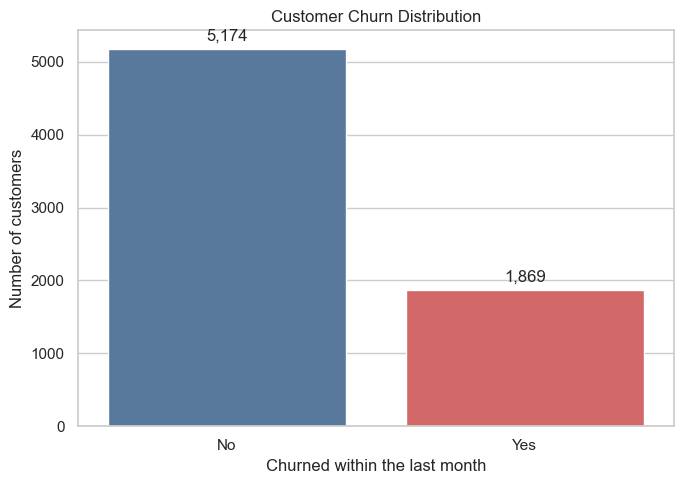

In [7]:
churn_counts = df["Churn"].value_counts(dropna=False)
churn_summary = pd.DataFrame({
    "customers": churn_counts,
    "percent": (churn_counts / len(df) * 100).round(2),
})
display(churn_summary)

fig, ax = plt.subplots(figsize=(7, 5))
sns.countplot(data=df, x="Churn", order=["No", "Yes"], ax=ax, hue="Churn",
              palette={"No": "#4C78A8", "Yes": "#E45756"}, legend=False)
ax.set(title="Customer Churn Distribution", xlabel="Churned within the last month", ylabel="Number of customers")
for bar in ax.patches:
    ax.annotate(f"{int(bar.get_height()):,}", (bar.get_x() + bar.get_width()/2, bar.get_height()),
                ha="center", va="bottom", xytext=(0, 4), textcoords="offset points")
plt.tight_layout()
plt.show()

## 7. Churn patterns by customer and account attributes

Rate charts show the share of customers who churned within each group. Tenure is shown as a distribution by churn status.

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_24948\1005566719.py:7: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:#4C78A8'` for the same effect.

  sns.barplot(data=plot_data, x=column, y="churn_rate", hue=column, legend=False, ax=ax, color="#4C78A8")


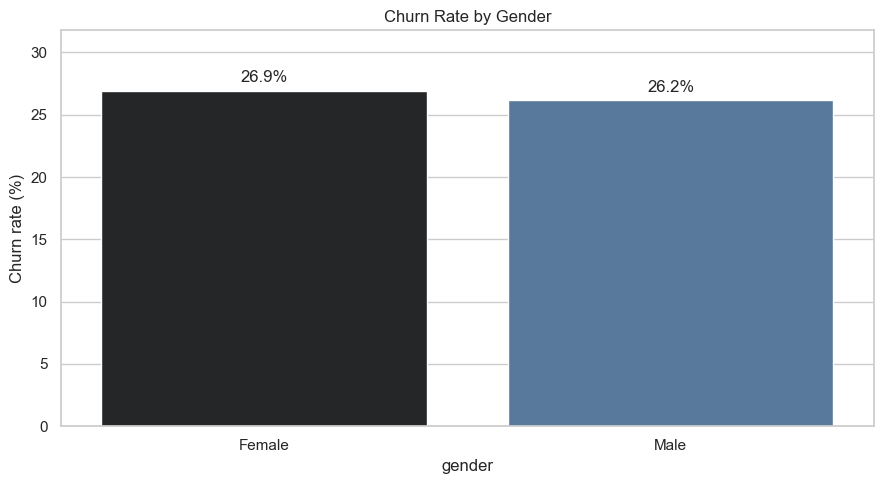

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_24948\1005566719.py:7: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:#4C78A8'` for the same effect.

  sns.barplot(data=plot_data, x=column, y="churn_rate", hue=column, legend=False, ax=ax, color="#4C78A8")


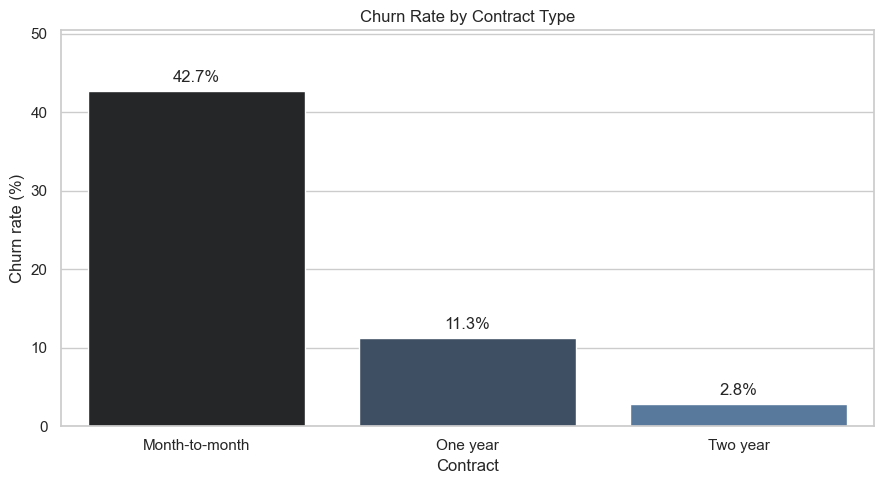

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_24948\1005566719.py:7: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:#4C78A8'` for the same effect.

  sns.barplot(data=plot_data, x=column, y="churn_rate", hue=column, legend=False, ax=ax, color="#4C78A8")


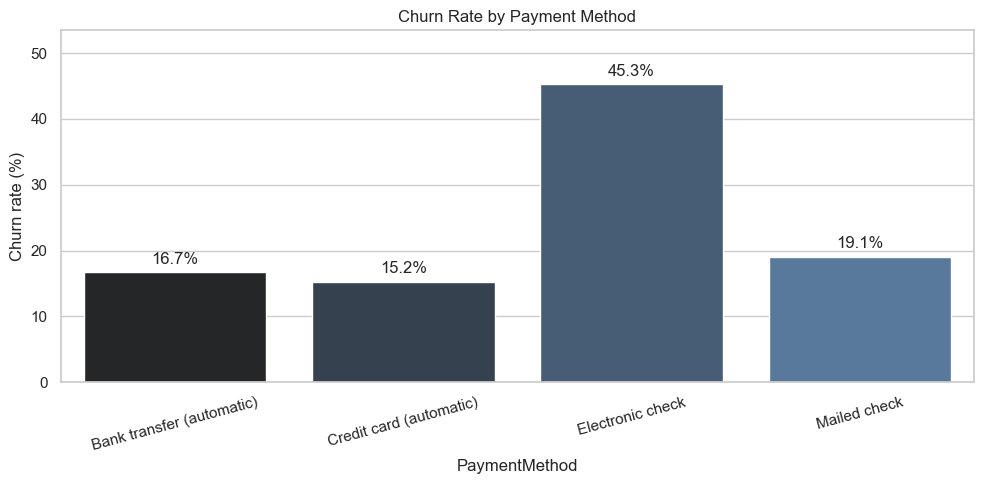

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_24948\1005566719.py:7: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:#4C78A8'` for the same effect.

  sns.barplot(data=plot_data, x=column, y="churn_rate", hue=column, legend=False, ax=ax, color="#4C78A8")


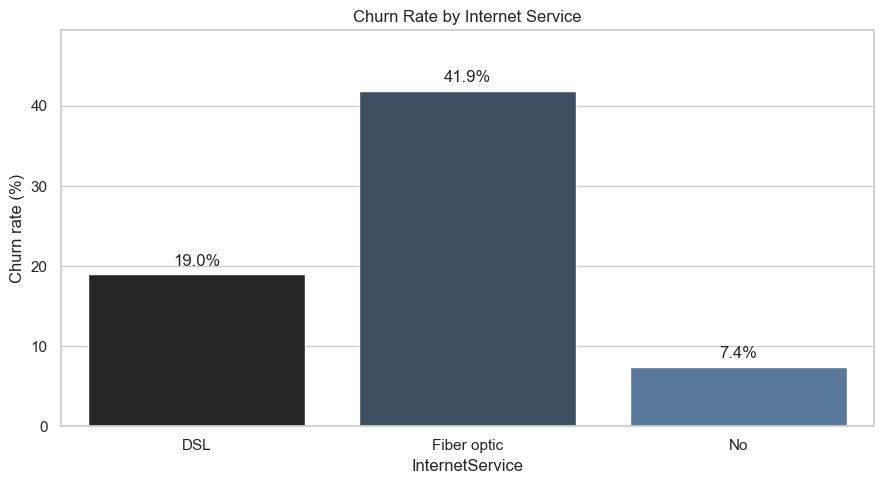

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_24948\1005566719.py:7: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:#4C78A8'` for the same effect.

  sns.barplot(data=plot_data, x=column, y="churn_rate", hue=column, legend=False, ax=ax, color="#4C78A8")


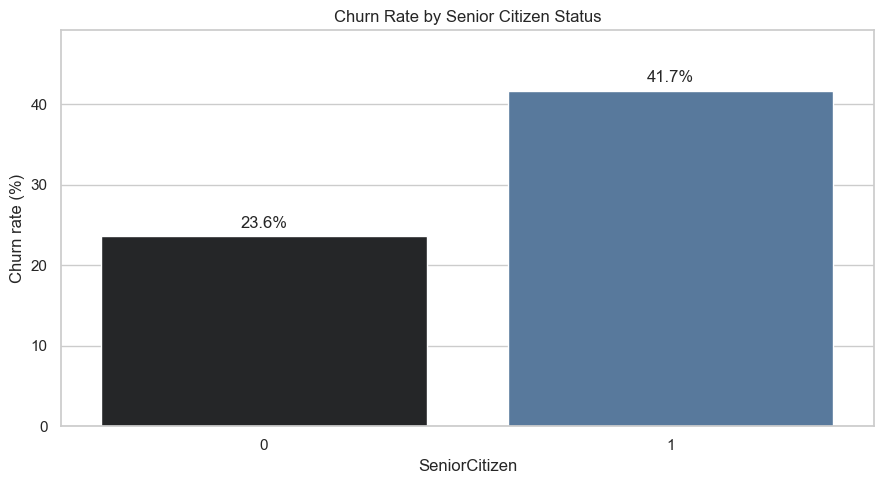

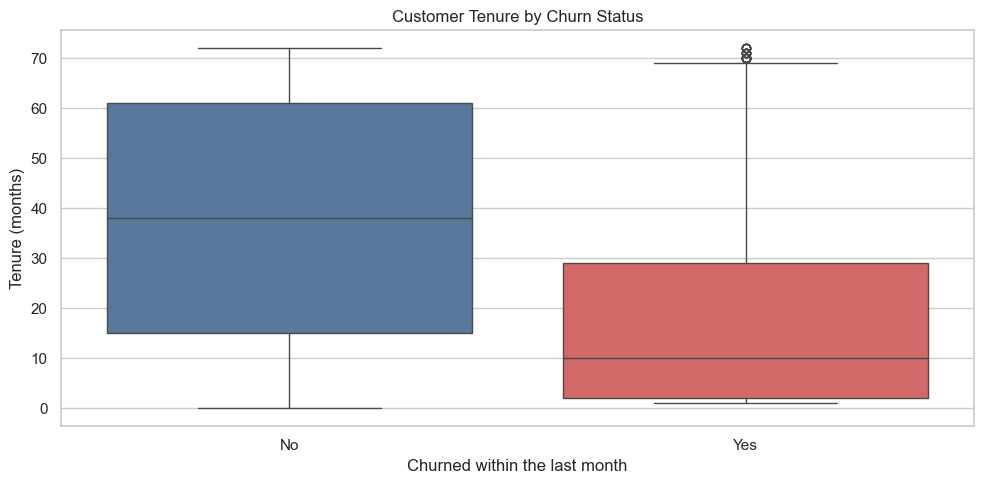

In [8]:
def plot_churn_rate(column, title, order=None, figsize=(9, 5), rotate=0):
    rates = df.groupby(column, observed=False)["Churn"].apply(lambda s: s.eq("Yes").mean() * 100)
    if order is not None:
        rates = rates.reindex(order)
    plot_data = rates.rename("churn_rate").reset_index()
    fig, ax = plt.subplots(figsize=figsize)
    sns.barplot(data=plot_data, x=column, y="churn_rate", hue=column, legend=False, ax=ax, color="#4C78A8")
    ax.set(title=title, xlabel=column, ylabel="Churn rate (%)")
    ax.set_ylim(0, max(10, float(rates.max()) * 1.18))
    ax.tick_params(axis="x", rotation=rotate)
    for bar in ax.patches:
        if np.isfinite(bar.get_height()):
            ax.annotate(f"{bar.get_height():.1f}%", (bar.get_x() + bar.get_width()/2, bar.get_height()),
                        ha="center", va="bottom", xytext=(0, 4), textcoords="offset points")
    plt.tight_layout()
    plt.show()
    return rates

churn_by_gender = plot_churn_rate("gender", "Churn Rate by Gender", order=["Female", "Male"])
churn_by_contract = plot_churn_rate("Contract", "Churn Rate by Contract Type",
                                    order=["Month-to-month", "One year", "Two year"])
churn_by_payment = plot_churn_rate("PaymentMethod", "Churn Rate by Payment Method", figsize=(10, 5), rotate=15)
churn_by_internet = plot_churn_rate("InternetService", "Churn Rate by Internet Service",
                                    order=["DSL", "Fiber optic", "No"])
churn_by_senior = plot_churn_rate("SeniorCitizen", "Churn Rate by Senior Citizen Status",
                                  order=[0, 1])

fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=df, x="Churn", y="tenure", order=["No", "Yes"], hue="Churn",
            palette={"No": "#4C78A8", "Yes": "#E45756"}, legend=False, ax=ax)
ax.set(title="Customer Tenure by Churn Status", xlabel="Churned within the last month", ylabel="Tenure (months)")
plt.tight_layout()
plt.show()

## 8. Charges by churn status

Compare monthly and cumulative charges across churn groups. `TotalCharges` excludes the 11 blank source values from its summary statistics; no replacement values are inserted.

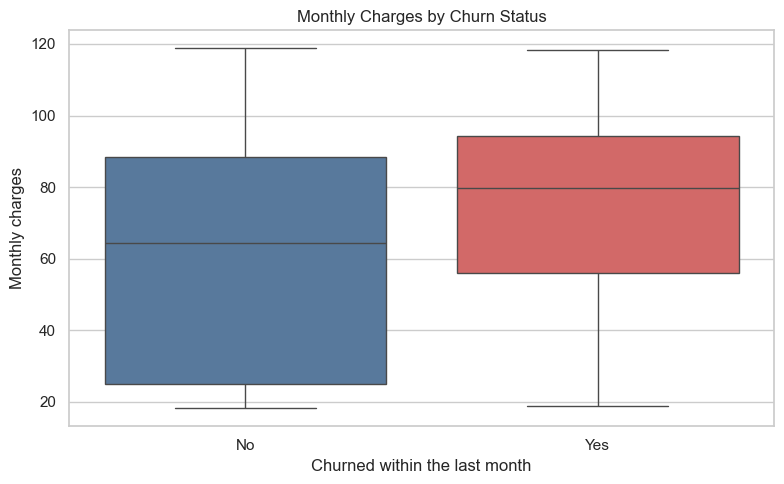

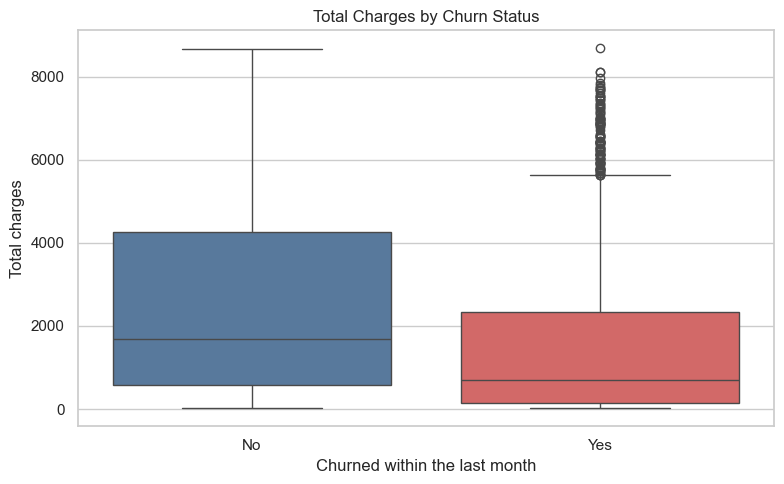

In [9]:
for charge_column, title, ylabel in [
    ("MonthlyCharges", "Monthly Charges by Churn Status", "Monthly charges"),
    ("TotalCharges", "Total Charges by Churn Status", "Total charges"),
]:
    fig, ax = plt.subplots(figsize=(8, 5))
    sns.boxplot(data=df, x="Churn", y=charge_column, order=["No", "Yes"], hue="Churn",
                palette={"No": "#4C78A8", "Yes": "#E45756"}, legend=False, ax=ax)
    ax.set(title=title, xlabel="Churned within the last month", ylabel=ylabel)
    plt.tight_layout()
    plt.show()

## 9. Tenure distribution

View the overall tenure distribution to understand how customer relationship lengths are represented.

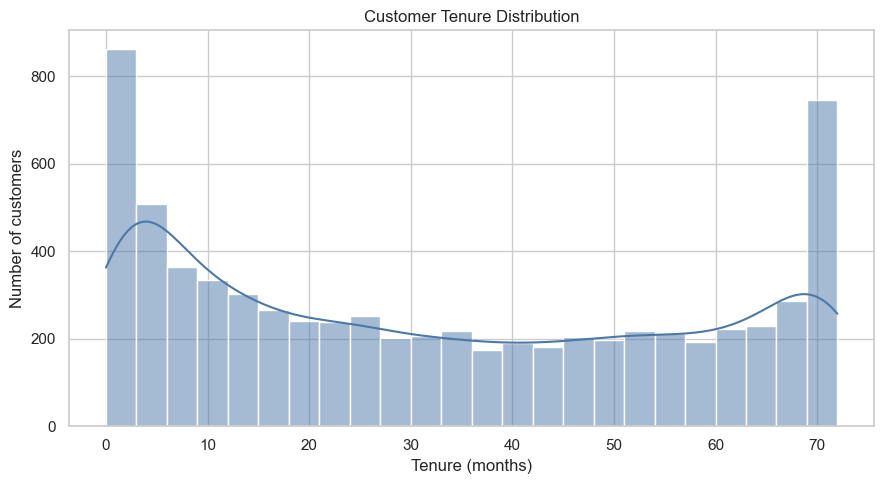

In [10]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.histplot(data=df, x="tenure", bins=24, kde=True, color="#4C78A8", ax=ax)
ax.set(title="Customer Tenure Distribution", xlabel="Tenure (months)", ylabel="Number of customers")
plt.tight_layout()
plt.show()

## 10. Key performance indicators

Average total charges use non-missing numeric values. Churn rate is churned customers divided by all customer rows.

In [11]:
total_customers = int(len(df))
churned_customers = int(df["Churn"].eq("Yes").sum())
kpis = pd.Series({
    "Total customers": total_customers,
    "Churned customers": churned_customers,
    "Churn rate (%)": df["Churn"].eq("Yes").mean() * 100,
    "Average monthly charges": df["MonthlyCharges"].mean(),
    "Average total charges (available values)": df["TotalCharges"].mean(),
    "Average tenure (months)": df["tenure"].mean(),
})
display(kpis.to_frame("value").round(2))

,value
Total customers,7043.00
Churned customers,1869.00
Churn rate (%),26.54
Average monthly charges,64.76
Average total charges (available values),2283.30
Average tenure (months),32.37


## 11. Export the cleaned copy

Save the cleaned DataFrame to `data/processed/customer_churn_cleaned.csv`. This export includes the numeric `TotalCharges` column and preserves blank totals as empty CSV fields (read back as missing values). The original raw file is not overwritten.

In [12]:
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
df.to_csv(CLEANED_PATH, index=False)
print(f"Saved cleaned dataset: {CLEANED_PATH}")
print(f"Cleaned dataset shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Cleaned TotalCharges missing values: {df['TotalCharges'].isna().sum():,}")

# Verify export can be read and has the expected dimensions and numeric TotalCharges.
cleaned_check = pd.read_csv(CLEANED_PATH)
assert cleaned_check.shape == df.shape
assert pd.api.types.is_numeric_dtype(cleaned_check["TotalCharges"])
assert int(cleaned_check["TotalCharges"].isna().sum()) == converted_missing
assert int(raw_df.duplicated().sum()) == raw_duplicate_count
print("Export verification passed; raw DataFrame was not modified.")

Saved cleaned dataset: C:\Users\Lenovo\OneDrive\Desktop\Customer360\data\processed\customer_churn_cleaned.csv
Cleaned dataset shape: 7,043 rows × 21 columns
Cleaned TotalCharges missing values: 11
Export verification passed; raw DataFrame was not modified.


## 12. Concise findings

The summary below reports calculated values directly from this dataset and avoids causal claims.

In [13]:
print(f"The dataset contains {total_customers:,} customers; {churned_customers:,} churned ({kpis['Churn rate (%)']:.2f}%).")
print(f"Average monthly charges are {kpis['Average monthly charges']:.2f}; average total charges are {kpis['Average total charges (available values)']:.2f} across non-missing totals.")
print(f"Average tenure is {kpis['Average tenure (months)']:.2f} months.")
print(f"Churn rates: month-to-month contracts {churn_by_contract.loc['Month-to-month']:.2f}%, one-year contracts {churn_by_contract.loc['One year']:.2f}%, two-year contracts {churn_by_contract.loc['Two year']:.2f}%.")
print(f"TotalCharges contains {converted_missing} missing values after numeric conversion; duplicate rows: {raw_duplicate_count}.")

The dataset contains 7,043 customers; 1,869 churned (26.54%).
Average monthly charges are 64.76; average total charges are 2283.30 across non-missing totals.
Average tenure is 32.37 months.
Churn rates: month-to-month contracts 42.71%, one-year contracts 11.27%, two-year contracts 2.83%.
TotalCharges contains 11 missing values after numeric conversion; duplicate rows: 0.
